In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

model = ChatGroq(
    model="llama-3.3-70b-versatile"
)
result = model.invoke(
   [
            
                HumanMessage(
                    content="hi, who are you? model provider and model name?"
                )
            
    ]
    
    
)
print(result)


content="Hello! I am an artificial intelligence language model, and I was created by Meta AI. My model name is LLAMA (Large Language Model Meta AI). I'm here to help answer your questions, provide information, and engage in conversation to the best of my abilities. How can I assist you today?" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 47, 'total_tokens': 109, 'completion_time': 0.192653014, 'completion_tokens_details': None, 'prompt_time': 0.005175372, 'prompt_tokens_details': None, 'queue_time': 0.319719947, 'total_time': 0.197828386}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019edb32-d366-7f53-80d5-4b8ec4baeb8a-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 47, 'output_tokens': 62, 'total_tokens': 109}


In [12]:
## Create a blue print to create specialized sub agents, basically when you create a Object of subagent this u have to initiate
from typing import NotRequired
from typing import List
from typing import TypedDict
class SubAgent(TypedDict):
    """COnfiguration for a specialized Sub Agent"""
    name: str # this main agent will use as Agent uniqueness whenever required
    description: str ## What does this sub agent do, this will also be used by main agent to find out what this sub agent can do
    tools: NotRequired[List[str]]
    instructions: str

We will use a list of these objects to create all the sub agents we have access to

In [13]:
agent1 = SubAgent(
    name="resercher",
    description="resercher",
    instructions="resercher"
)

In [14]:
sub_agent_list = []
sub_agent_list.append(agent1)
print(sub_agent_list)

[{'name': 'resercher', 'description': 'resercher', 'instructions': 'resercher'}]


In [16]:
from langchain_core.tools import BaseTool, InjectedToolCallId, tool
from langchain_core.messages import ToolMessage
from langgraph.types import Command
from langchain_core.messages import HumanMessage
from state import DeepAgentState
from langgraph.prebuilt import InjectedState
from typing import Annotated
from prompts import TASK_DESCRIPTION_PREFIX
from langchain.agents import create_agent
from pydantic import InstanceOf

/Users/nitinaggarwal/Documents/learning/langgraph_deep_agents/.venv/lib/python3.12/site-packages/langgraph/checkpoint/base/__init__.py:17: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [25]:
def _create_task_tool(
    tools,
    subagents:list[SubAgent],
    model,
    state_schema
):
    """Create a task delegation tool that enables context isolation through sub-agents.

    This function implements the core pattern for spawning specialized sub-agents with
    isolated contexts, preventing context clash and confusion in complex multi-step tasks.

    Args:
        tools: List of available tools that can be assigned to sub-agents
        subagents: List of specialized sub-agent configurations
        model: The language model to use for all agents
        state_schema: The state schema (typically DeepAgentState)

    Returns:
        A 'task' tool that can delegate work to specialized sub-agents
    """
    # Create agent registry
    agents = {}

    # Build tool name mapping for selective tool assignment
    tools_by_name = {}


    """Convert input tools to LangChain BaseTool objects if they aren't already,
    and build a name-to-tool lookup dictionary for selective sub-agent assignment.
    """
    for tool_ in tools:
        if not isinstance(tool_,BaseTool):
            tool_ = tool(tool_)
        tools_by_name[tool_.name] = tool_

    ### spawn specialized sub-agents from subagent configuration
    for _agent in subagents:
        if "tools" in _agent:
            ## Use specified tools in agents from 
            _tools =[]
            for t in _agent["tools"]:
                _tools.append(tools_by_name[t])
        else:
            _tools = tools
        agents[_agent["name"]] = create_agent(
            model=model,
            tools = _tools,
            system_prompt=_agent["instructions"],
            state_schema=state_schema
        )

    other_agents_string = [f" - {_agent['name']}:{_agent['description']}" for _agent in subagents]

    @tool(description=TASK_DESCRIPTION_PREFIX.format(other_agents=other_agents_string))
    def task(
        description:str,
        subagent_type:str,
        tool_call_id:Annotated[str,InjectedToolCallId],
        state:Annotated[DeepAgentState,InjectedState]
    ):
        """Delegate a task to a specialized sub-agent with isolated context.

        This creates a fresh context for the sub-agent containing only the task description,
        preventing context pollution from the parent agent's conversation history.
        """
        # Validate requested agent type exists
        if subagent_type not in agents:
            return f"Error: Requested sub agent type :{subagent_type} is not available, the only allowed types are {[f'`{k}`' for k in agents]}"
        ## Get the requested sub-agent
        sub_agent = agents[subagent_type]
        # Create isolated context with only the task description
        # This is the key to context isolation - no parent history
        state["messages"] = [HumanMessage(content=description)]
        result = sub_agent.invoke(state)
        tool_last_message = result["messages"][-1].content
        return Command(
            update={
                "files":"",
                "messages":[
                    ToolMessage(
                        tool_last_message,tool_call_id=tool_call_id
                    )
                ]
            }
        )
    
    return task


In [17]:
from utils import show_prompt
from prompts import SUBAGENT_USAGE_INSTRUCTIONS

show_prompt(SUBAGENT_USAGE_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You can delegate tasks to sub-agents.                                                                          │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your role is to coordinate research by delegating specific research tasks to sub-agents.                       │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  1. **task(description, subagent_type)**: Delegate research tasks to specialized sub-agents                     │
│     - description: Clear, specific research question or task                                                    │
│     - subagent_type: Type of agent to use (e.g., "research-agent")                                              │
│  2. **think_tool(reflection)**: Reflect on the results of each delegated task and plan next steps.              │
│     - reflection: Your detailed reflection on the results of the task and next steps.                           │
│                                                                                                                 │
│  **PARALLEL RESEARCH**: When you identify multiple independent research directions, make multiple **task**      │
│  tool calls in a single response to enable parallel execution. Use at most {max_concurrent_research_units}      │
│  parallel agents per iteration.                                                                                 │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Task Delegation Budgets** (Prevent excessive delegation):                                                    │
│  - **Bias towards focused research** - Use single agent for simple questions, multiple only when clearly        │
│  beneficial or when you have multiple independent research directions based on the user's request.              │
│  - **Stop when adequate** - Don't over-research; stop when you have sufficient information                      │
│  - **Limit iterations** - Stop after {max_researcher_iterations} task delegations if you haven't found          │
│  adequate sources                                                                                               │
│  </Hard Limits>                                                                                                 │
│                                                                                                                 │
│  <Scaling Rules>                                                                                                │
│  **Simple fact-finding, lists, and rankings** can use a single sub-agent:                                       │
│  - *Example*: "List the top 10 coffee shops in San Francisco" → Use 1 sub-agent, store in                       │
│  `findings_coffee_shops.md`                                                                                     │
│                                                                                                                 │
│  **Comparisons** can use a sub-agent for each element 

In [18]:
## Limits
max_concurrent_research_units=3
max_researcher_iterations=3
# Mock Search Result
search_result = """The Model Context Protocol (MCP) is an open standard protocol developed 
by Anthropic to enable seamless integration between AI models and external systems like 
tools, databases, and other services. It acts as a standardized communication layer, 
allowing AI models to access and utilize data from various sources in a consistent and 
efficient manner. Essentially, MCP simplifies the process of connecting AI assistants 
to external services by providing a unified language for data exchange. """

@tool(parse_docstring=True)
def web_search(
    query:str
) -> str:
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from the search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    return search_result

In [20]:
# Add mock research instructions
SIMPLE_RESEARCH_INSTRUCTIONS = """You are a researcher. Research the topic provided to you. IMPORTANT: Just make a single call to the web_search tool and use the result provided by the tool to answer the provided topic."""

research_sub_agent = {
    "name":"research_agent",
    "description":"Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "tools":["web_search"],
    "instructions":SIMPLE_RESEARCH_INSTRUCTIONS
}


In [21]:
from langchain.chat_models import init_chat_model
model = init_chat_model(
    model="google_genai:gemini-3.5-flash",
    temprature=0.0
)

Unexpected argument 'temprature' provided to ChatGoogleGenerativeAI. Did you mean: 'temperature'?
/Users/nitinaggarwal/Documents/learning/langgraph_deep_agents/.venv/lib/python3.12/site-packages/langchain/chat_models/base.py:314: UserWarning: WARNING! temprature is not default parameter.
                temprature was transferred to model_kwargs.
                Please confirm that temprature is what you intended.
  return _init_chat_model_helper(


In [22]:
sub_agent_tools = [web_search]

In [27]:
task_tool = _create_task_tool(
    sub_agent_tools,
    [research_sub_agent],
    model,
    DeepAgentState
)
delegation_tools = [task_tool]

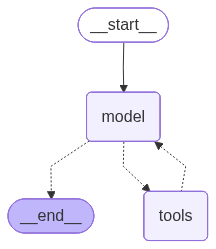

In [28]:
# Create the main agent with system Prompt

from IPython.display import Image,display
from datetime import datetime
main_agent = create_agent(
    model=model,
    tools=delegation_tools,
    system_prompt=SUBAGENT_USAGE_INSTRUCTIONS.format(
        max_researcher_iterations=max_researcher_iterations,
        max_concurrent_research_units=max_concurrent_research_units,
        date=datetime.now().strftime("%a %b %-d, %Y"),
    ),
    state_schema=DeepAgentState
)
# Show the agent
display(Image(main_agent.get_graph(xray=True).draw_mermaid_png()))

In [29]:
from utils import format_messages
result = main_agent.invoke(
    {
        "messages":[
            HumanMessage(content="Give me an overview of the Model Context Protocol (MCP)")
        ]
    }
)
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an overview of the Model Context Protocol (MCP)                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "description": "Research the Model Context Protocol (MCP). Provide a comprehensive overview including: 1.     │
│ What is MCP and who created it? 2. What core problem does it solve? 3. Explain its architecture                 │
│ (Client-Server-Host model). 4. Detail its primary components (Resources, Prompts, Tools). 5. Give examples of   │
│ current implementations, clients, and servers. 6. What are the key benefits for developers and AI               │
│ applications?",                                                                                                 │
│   "subagent_type": "research_agent"                                                                             │
│ }                                                                                                               │
│    ID: 750xr5ta                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ # Comprehensive Overview of the Model Context Protocol (MCP)                                                    │
│                                                                                                                 │
│ The **Model Context Protocol (MCP)** is an open-source standard designed to revolutionize how artificial        │
│ intelligence models interact with data sources and tools. Officially announced by **Anthropic** in late 2024,   │
│ MCP acts as an open-standard communication layer that enables developer tools and AI assistants to seamlessly   │
│ and securely integrate with diverse data environments.                                                          │
│                                                                                                                 │
│ Below is a comprehensive breakdown of the protocol, its architecture, core components, and its significance to  │
│ the AI ecosystem.                                                                                               │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 1. What is MCP and Who Created It?                                                                          │
│ **Model Context Protocol (MCP)** is an open-source, standardized protocol developed by **Anthropic**.           │
│                                                                                                                 │
│ Often described as the **"USB-C port for AI applications,"** MCP provides a unified, symmetrical protocol for   │
│ data exchange. Just as USB-C replaced a chaotic landscape of proprietary chargers and data cables with a single │
│ standard, MCP replaces fragmented, proprietary APIs with a single standard for connecting Large Language Models │
│ (LLMs) to data sources and developer utilities.                                                                 │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 2. What Core Problem Does It Solve?                                                                         │
│ Before MCP, connecting AI assistants to data repositories (like databases, local filesystems, SaaS products,    │
│ and APIs) suffered from a severe scaling bottleneck known as the **$M \times N$ integration problem**:          │
│ * **The Fragmentation Dilemma:** If there are $M$ different AI clients (e.g., Claude Desktop, Cursor IDE,       │
│ Copilot, custom internal tools) and $N$ different data sources or tools (e.g., GitHub, Slack, Postgres, Jira),  │
│ developers had to write custom integration "glue code" for almost every combination.                            │
│ * **Maintainability Issues:** Whenever a data source API changed or a new LLM client emerged, integrations had  │
│ to be rewritten or heavily modified.                                                                            │
│ * **Context Isolation:** AI models remained isolated from real-time local context (like codebases, databases,   │
│ and local documents), limiting their usefulness or forcing developers to upload sensitive data to third-party   │
│ servers.                                                                                                        │
│                                                        

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ The **Model Context Protocol (MCP)** is an open-source standard designed to revolutionize how artificial        │
│ intelligence models interact with data sources and tools. Officially announced by **Anthropic** in late 2024,   │
│ MCP acts as an open-standard communication layer that enables developer tools and AI assistants to seamlessly   │
│ and securely integrate with diverse data environments.                                                          │
│                                                                                                                 │
│ Often described as the **"USB-C port for AI applications,"** MCP replaces a chaotic landscape of proprietary    │
│ APIs and custom integrations with a single, unified standard.                                                   │
│                                                                                                                 │
│ Here is a comprehensive overview of the Model Context Protocol, its architecture, core components, and its      │
│ significance to the AI ecosystem.                                                                               │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 1. The Core Problem MCP Solves                                                                              │
│ Before MCP, connecting AI assistants to data repositories (like databases, local filesystems, SaaS products,    │
│ and APIs) suffered from a severe scaling bottleneck known as the **$M \times N$ integration problem**:          │
│ * **The Fragmentation Dilemma:** If there are $M$ different AI clients (e.g., Claude Desktop, Cursor IDE,       │
│ Copilot, custom internal tools) and $N$ different data sources or tools (e.g., GitHub, Slack, Postgres, Jira),  │
│ developers had to write custom integration "glue code" for almost every combination.                            │
│ * **High Maintenance:** Whenever a data source API changed or a new LLM client emerged, integrations had to be  │
│ rewritten or heavily modified.                                                                                  │
│ * **Context Isolation:** AI models remained isolated from real-time local context (like codebases, databases,   │
│ and local documents), limiting their usefulness or forcing developers to upload sensitive data to third-party   │
│ servers.                                                                                                        │
│                                                                                                                 │
│ **MCP solves this** by introducing a standard intermediary. Instead of writing custom integrations for every    │
│ tool-client pair, developers only need to build an **MCP Server** for their data source once. Any               │
│ **MCP-compliant Client** can then immediately connect to it, reducing integration complexity from $M \times N$  │
│ to a simple, scalable architecture.                                                                             │
│                                                                                                                 │
│ ```                                                                                                             │
│ OLD WAY (Proprietary & Fragmented):                                                                             │
│ [Claude Desktop] <--> Custom Code <--> [Postgres]                                                               │
│ [Cursor IDE]     <--> Custom Code <--> [Postgres]      